In [57]:
# Numerical & data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilities
import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


In [58]:
# Load dataset
df = pd.read_csv("solarpowergeneration (2).csv")

In [59]:
# Display first few rows
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [60]:
df.info()  #Display dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [61]:
df.describe()   #Display Statistical Summary

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2919.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.261547,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [62]:
TARGET = "power-generated"   # Joules (Target)

In [63]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

In [64]:
# Fill missing values using median (robust for weather data)
df.fillna(df.median(), inplace=True)       #missing value is handled using median imputation

In [65]:
df.isnull().sum()             #re-checked missing values

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

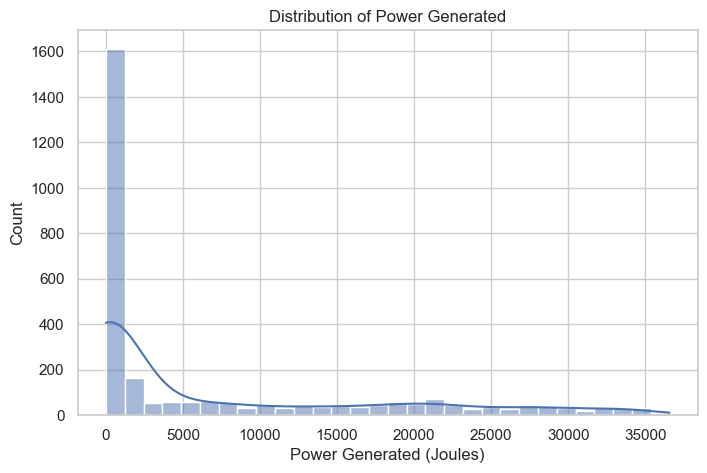

In [66]:
#Histogram- 
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET], bins=30, kde=True)
plt.title("Distribution of Power Generated")
plt.xlabel("Power Generated (Joules)")
plt.show()

#highly right skewed, long tail

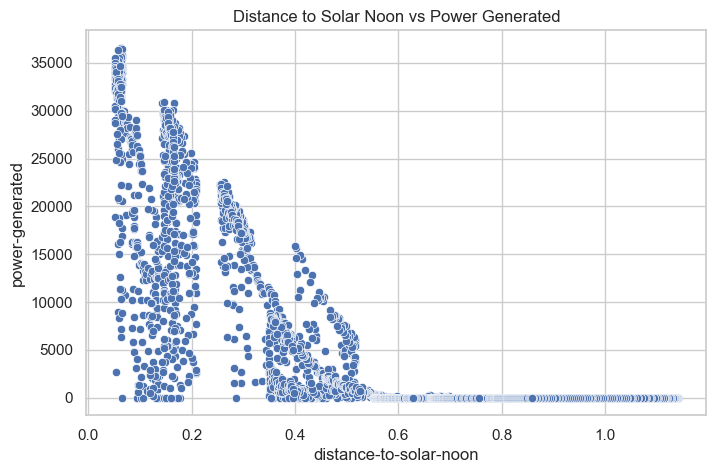

In [67]:
#scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x="distance-to-solar-noon", y=TARGET, data=df)
plt.title("Distance to Solar Noon vs Power Generated")
plt.show()


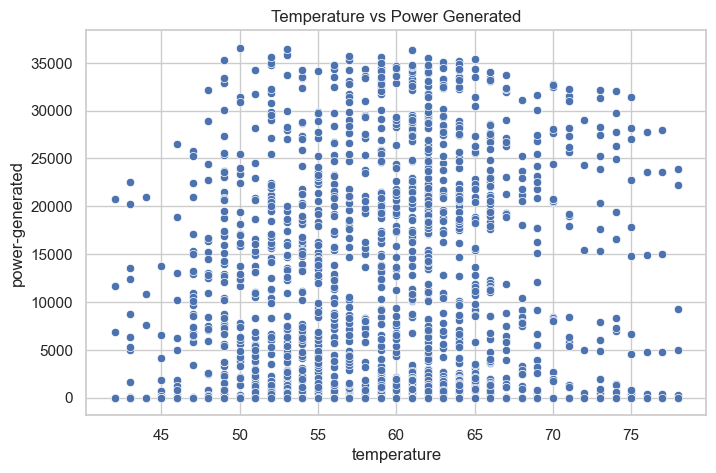

In [68]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="temperature", y=TARGET, data=df)
plt.title("Temperature vs Power Generated")
plt.show()


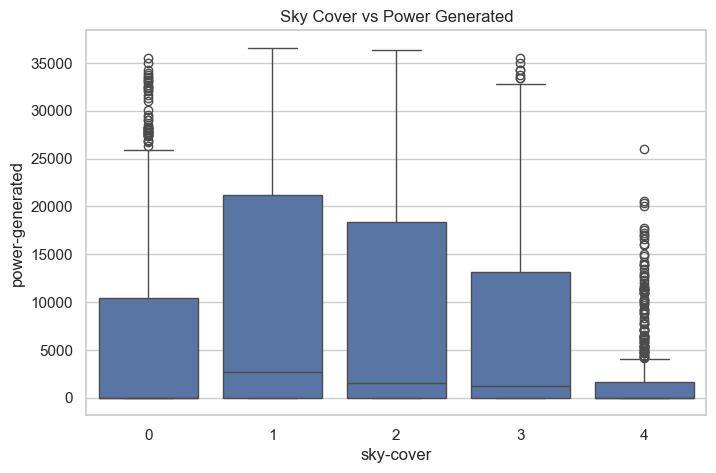

In [69]:
plt.figure(figsize=(8,5))
sns.boxplot(x="sky-cover", y=TARGET, data=df)
plt.title("Sky Cover vs Power Generated")
plt.show()


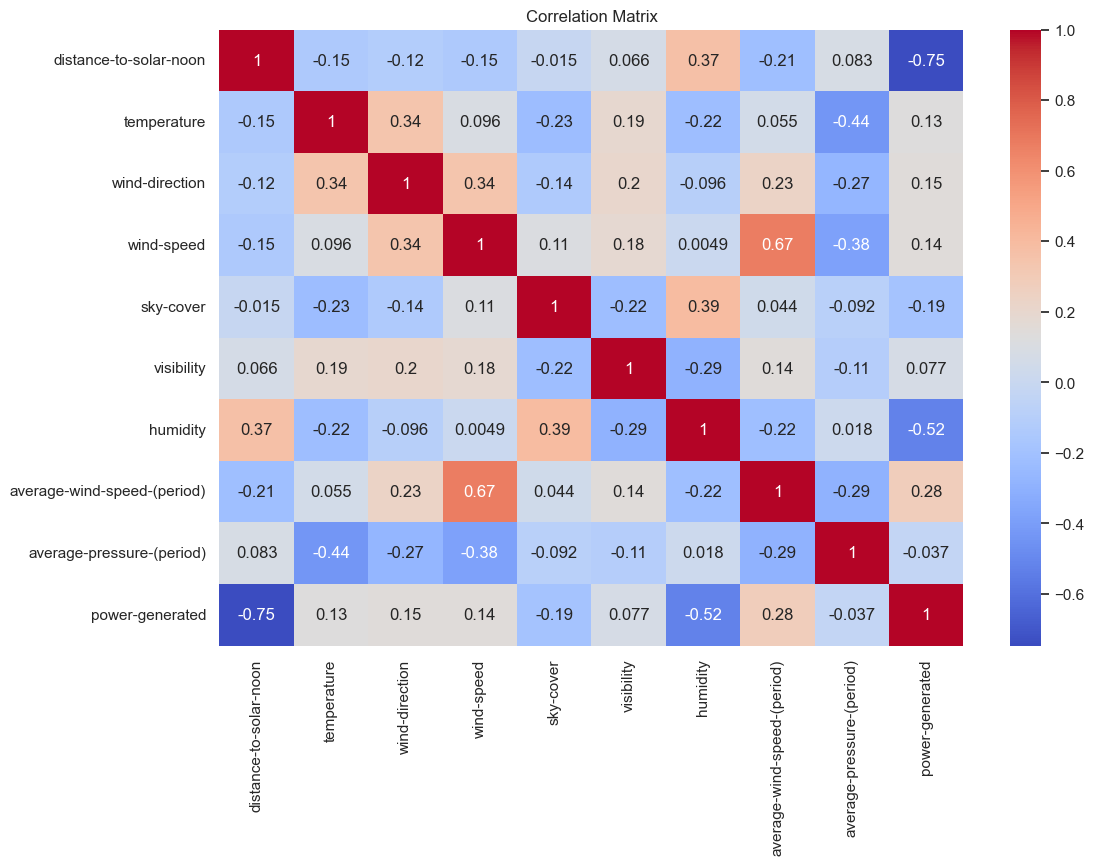

In [70]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Feature Engineering

In [71]:
df['lag_1'] = df['power-generated'].shift(1)
df['lag_2'] = df['power-generated'].shift(2)
df['rolling_mean_3'] = df['power-generated'].rolling(3).mean()
df['rolling_mean_6'] = df['power-generated'].rolling(6).mean()

df.dropna(inplace=True)


In [72]:
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated,lag_1,lag_2,rolling_mean_3,rolling_mean_6
5,0.296915,69,28,7.5,0,10.0,20,23.0,29.85,16280,30069.0,25477.0,23942.000000,12874.000000
6,0.528278,69,28,7.5,0,10.0,36,15.0,29.83,515,16280.0,30069.0,15621.333333,12959.833333
7,0.759640,69,28,7.5,0,10.0,49,6.0,29.86,0,515.0,16280.0,5598.333333,12959.833333
8,0.862113,72,29,6.8,0,10.0,67,6.0,29.86,0,0.0,515.0,171.666667,12056.833333
9,0.630155,72,29,6.8,0,10.0,49,0.0,29.87,0,0.0,0.0,0.000000,7810.666667


Model Building

In [73]:

features = [ 'distance-to-solar-noon',
             'temperature',
             'wind-direction',
             'wind-speed',
             'sky-cover',
             'lag_1','lag_2','rolling_mean_3','rolling_mean_6']

X = df[features]
y = df['power-generated']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)


In [74]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)


In [75]:

print("MAE :", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2  :", r2_score(y_test, preds))


MAE : 503.4269982847341
RMSE: 1043.8403312250098
R2  : 0.9926491418039779


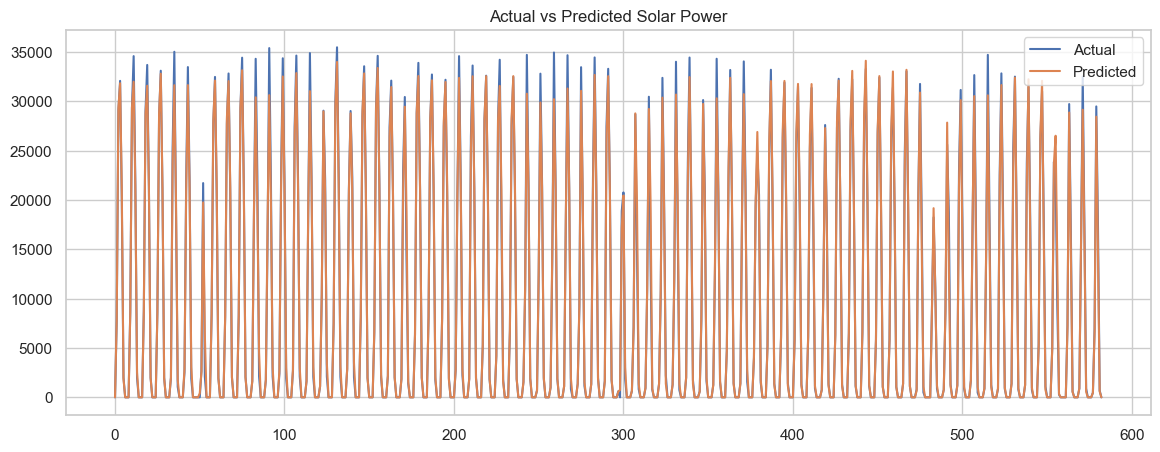

In [76]:

plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Solar Power")
plt.show()


In [77]:

last_row = df[features].iloc[-1:]
last_row_scaled = scaler.transform(last_row)
future_power = rf.predict(last_row_scaled)
future_power


array([0.])

In [78]:

pickle.dump(rf, open("rf_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
